# Dimensionality Reduction & Principal Component Analysis (PCA)

---

## 1. Dimensionality Reduction

### Apa itu Dimensionality Reduction?

**Dimensionality Reduction** adalah proses mereduksi jumlah fitur (dimensi) dalam sebuah dataset, sambil tetap mempertahankan informasi yang paling penting. Dalam konteks machine learning dan data science, "dimensi" merujuk pada jumlah variabel/fitur yang ada dalam data.

### Mengapa Dimensionality Reduction Diperlukan?

Ketika bekerja dengan data berdimensi tinggi, kita seringkali menghadapi masalah yang dikenal sebagai **"Curse of Dimensionality"** — fenomena di mana performa model justru menurun seiring bertambahnya fitur, karena data menjadi semakin "jarang" (sparse) di ruang berdimensi tinggi.

**Masalah umum data berdimensi tinggi:**
- Waktu komputasi yang lama
- Risiko overfitting meningkat
- Visualisasi data menjadi mustahil (manusia hanya dapat memahami hingga 3 dimensi)
- Banyak fitur yang redundan atau tidak relevan

### Jenis-Jenis Dimensionality Reduction

| Kategori | Metode | Keterangan |
|---|---|---|
| **Feature Selection** | Filter, Wrapper, Embedded | Memilih subset fitur asli yang paling relevan |
| **Feature Extraction** | PCA, LDA, t-SNE, UMAP, Autoencoder | Membuat representasi baru dari kombinasi fitur asli |

---

## 2. Principal Component Analysis (PCA)

### Definisi

**PCA (Principal Component Analysis)** adalah teknik *unsupervised* dimensionality reduction yang mentransformasi data ke dalam sistem koordinat baru, di mana dimensi-dimensi baru (disebut **Principal Components / PC**) diurutkan berdasarkan varians yang mereka jelaskan — dari yang terbesar hingga terkecil.

> PCA mencari arah (vektor) di mana data memiliki **varians maksimum**, sehingga proyeksi data ke arah tersebut mempertahankan informasi sebanyak mungkin.


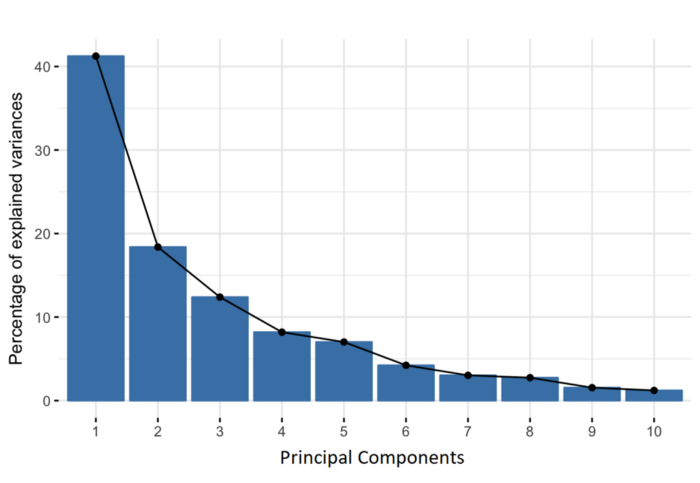

Bayangkan data 2D berbentuk elips. PCA akan menemukan:
- **PC1** → sumbu terpanjang elips (arah varians terbesar)
- **PC2** → sumbu terpendek elips (tegak lurus terhadap PC1)

Jika PC1 sudah menjelaskan 95% varians, kita bisa membuang PC2 dan mereduksi data dari 2D → 1D dengan kehilangan informasi yang minimal.

---

## 3. Langkah-Langkah Melakukan PCA

### Langkah 0: Persiapan Data

Sebelum PCA dilakukan, pastikan data telah melalui tahap preprocessing berikut:

#### ✅ A. Penanganan Missing Values
Data tidak boleh mengandung nilai kosong (NaN). Tangani dengan:
- Imputasi (mean, median, modus)
- Penghapusan baris/kolom

#### ✅ B. Encoding Variabel Kategorikal
PCA hanya bekerja pada data **numerik**. Variabel kategorikal harus di-encode terlebih dahulu (One-Hot Encoding, Label Encoding, dll.).

#### ✅ C. Deteksi dan Penanganan Outlier
Outlier dapat mendistorsi perhitungan varians secara signifikan. Identifikasi menggunakan IQR, Z-score, atau visualisasi boxplot.

---

### Langkah 1: Standardisasi / Normalisasi Data

PCA sangat sensitif terhadap **skala** fitur. Fitur dengan nilai besar akan mendominasi komponen utama, meskipun tidak lebih informatif. Oleh karena itu, standarisasi wajib dilakukan.

**Rumus Standardisasi (Z-score normalization):**

$$z_i = \frac{x_i - \mu}{\sigma}$$

Di mana:
- $x_i$ = nilai fitur ke-$i$
- $\mu$ = rata-rata fitur
- $\sigma$ = standar deviasi fitur

Setelah standardisasi, setiap fitur memiliki **mean = 0** dan **standar deviasi = 1**.

---

### Langkah 2: Hitung Covariance Matrix

Covariance matrix menunjukkan bagaimana setiap pasang fitur bervariasi bersama-sama (hubungan linear antar fitur).

**Rumus Covariance antar dua fitur $X$ dan $Y$:**

$$\text{Cov}(X, Y) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$

**Untuk dataset dengan $p$ fitur**, covariance matrix $\Sigma$ berukuran $p \times p$:

$$\Sigma = \frac{1}{n-1} \mathbf{X}^T \mathbf{X}$$

Di mana $\mathbf{X}$ adalah matriks data yang sudah distandarisasi (berukuran $n \times p$).

**Sifat covariance matrix:**
- Simetris: $\Sigma_{ij} = \Sigma_{ji}$
- Diagonal berisi varians masing-masing fitur
- Off-diagonal berisi covariance antar fitur

---

### Langkah 3: Hitung Eigenvalues dan Eigenvectors

Inti dari PCA adalah dekomposisi covariance matrix menjadi **eigenvalues** dan **eigenvectors**.

**Persamaan Eigen:**

$$\Sigma \mathbf{v} = \lambda \mathbf{v}$$

Di mana:
- $\Sigma$ = covariance matrix
- $\mathbf{v}$ = eigenvector (arah principal component)
- $\lambda$ = eigenvalue (besarnya varians yang dijelaskan oleh PC tersebut)

**Interpretasi:**
- **Eigenvector** → menentukan **arah** principal component di ruang fitur asli
- **Eigenvalue** → menentukan **besarnya varians** yang dijelaskan oleh PC tersebut

> **Semakin besar eigenvalue, semakin penting principal component tersebut.**

---

### Langkah 4: Urutkan Eigenvalues (Pilih Principal Components)

Setelah mendapatkan semua pasangan $(\lambda_i, \mathbf{v}_i)$, urutkan dari eigenvalue terbesar ke terkecil:

$$\lambda_1 \geq \lambda_2 \geq \lambda_3 \geq \cdots \geq \lambda_p$$

**Explained Variance Ratio** untuk setiap PC:

$$\text{EVR}_k = \frac{\lambda_k}{\sum_{i=1}^{p} \lambda_i}$$

**Cumulative Explained Variance:**

$$\text{Cumulative EVR}_k = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{p} \lambda_i}$$

**Menentukan jumlah PC yang dipertahankan:**
- Pilih $k$ PC pertama yang memberikan **cumulative explained variance ≥ 80–95%**
- Gunakan **Scree Plot** (grafik eigenvalue vs. nomor PC) dan cari "elbow point"

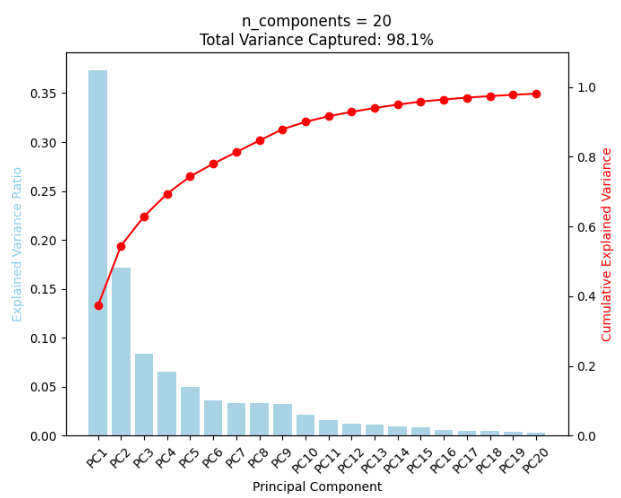

---

### Langkah 5: Bentuk Feature Vector (Projection Matrix)

Pilih $k$ eigenvector teratas dan susun menjadi **projection matrix** $\mathbf{W}$:

$$\mathbf{W} = [\mathbf{v}_1, \mathbf{v}_2, \ldots, \mathbf{v}_k] \quad \text{berukuran } p \times k$$

---

### Langkah 6: Transformasi Data ke Dimensi Baru

Proyeksikan data asli ke ruang berdimensi lebih rendah menggunakan projection matrix:

$$\mathbf{Z} = \mathbf{X} \cdot \mathbf{W}$$

Di mana:
- $\mathbf{X}$ = matriks data terstandarisasi ($n \times p$)
- $\mathbf{W}$ = projection matrix ($p \times k$)
- $\mathbf{Z}$ = data yang telah direduksi (**$n \times k$**) ← hasil akhir PCA

---

## 4. Ringkasan Alur PCA

```
Data Mentah
    │
    ▼
[Preprocessing]
  - Handle missing values
  - Encode categorical variables
  - Remove/handle outliers
    │
    ▼
[Standardisasi]  →  z = (x - μ) / σ
    │
    ▼
[Covariance Matrix]  →  Σ = (1/n-1) XᵀX
    │
    ▼
[Eigen Decomposition]  →  Σv = λv
    │
    ▼
[Pilih k PC terbaik]  →  berdasarkan Explained Variance
    │
    ▼
[Proyeksi Data]  →  Z = X · W
    │
    ▼
Data Tereduksi (n × k)
```

---

## 5. Kelebihan dan Kekurangan PCA

| | Kelebihan | Kekurangan |
|---|---|---|
| ✅ | Mengurangi kompleksitas komputasi | Komponen baru sulit diinterpretasikan secara langsung |
| ✅ | Menghilangkan multikolinearitas antar fitur | Hanya menangkap hubungan **linear** antar fitur |
| ✅ | Membantu visualisasi data (proyeksi ke 2D/3D) | Kehilangan sebagian informasi (lossy compression) |
| ✅ | Mengurangi risiko overfitting | Sensitif terhadap outlier (wajib preprocessing) |
| ✅ | Bekerja baik pada data berdimensi sangat tinggi | Wajib standardisasi terlebih dahulu |

---

## 6. Kapan Menggunakan PCA?

- Jumlah fitur sangat banyak dan diduga banyak yang redundan
- Ingin memvisualisasikan data berdimensi tinggi
- Ingin menghilangkan multikolinearitas sebelum regresi
- Sebagai preprocessing sebelum clustering atau klasifikasi
- Kompresi data dengan kehilangan informasi minimal

> **Catatan:** PCA bukan selalu solusi terbaik. Untuk data dengan hubungan **non-linear**, pertimbangkan metode seperti **t-SNE**, **UMAP**, atau **Kernel PCA**.

---

*Referensi: Bishop, C.M. (2006). Pattern Recognition and Machine Learning. | Jolliffe, I.T. (2002). Principal Component Analysis.*

# Contoh Perhitungan Manual PCA (Step-by-Step)

> Dokumen ini merupakan kelanjutan dari **Dimensionality Reduction & PCA**.  
> Kita akan mereduksi dataset **4 sampel × 2 fitur** menjadi **1 dimensi (PC1)** secara manual.

---

## Dataset Awal

Misalkan kita memiliki dataset kecil dengan 2 fitur: **Tinggi Badan (cm)** dan **Berat Badan (kg)**.

| Sampel | $X_1$ (Tinggi) | $X_2$ (Berat) |
|:------:|:--------------:|:-------------:|
| A      | 170            | 65            |
| B      | 160            | 55            |
| C      | 180            | 75            |
| D      | 150            | 50            |

Tujuan: Reduksi dari **2 fitur → 1 PC** menggunakan PCA manual.

---

## Langkah 0: Cek Preprocessing

✅ Tidak ada missing values  
✅ Semua fitur sudah numerik  
✅ Tidak ada outlier ekstrem  

→ Data siap untuk distandarisasi.

---

## Langkah 1: Standardisasi Data

**Hitung Mean dan Standar Deviasi masing-masing fitur:**

$$\mu_{X_1} = \frac{170 + 160 + 180 + 150}{4} = \frac{660}{4} = 165$$

$$\mu_{X_2} = \frac{65 + 55 + 75 + 50}{4} = \frac{245}{4} = 61.25$$

---

**Varians (menggunakan $n-1$ / sample variance):**

$$\sigma^2_{X_1} = \frac{(170-165)^2 + (160-165)^2 + (180-165)^2 + (150-165)^2}{4-1}$$

$$= \frac{25 + 25 + 225 + 225}{3} = \frac{500}{3} \approx 166.67$$

$$\sigma_{X_1} = \sqrt{166.67} \approx 12.91$$

---

$$\sigma^2_{X_2} = \frac{(65-61.25)^2 + (55-61.25)^2 + (75-61.25)^2 + (50-61.25)^2}{3}$$

$$= \frac{14.0625 + 39.0625 + 189.0625 + 126.5625}{3} = \frac{368.75}{3} \approx 122.92$$

$$\sigma_{X_2} = \sqrt{122.92} \approx 11.09$$

---

**Hitung nilai terstandarisasi** $z = \frac{x - \mu}{\sigma}$ untuk setiap sampel:

**Fitur $X_1$ (Tinggi):**

$$z_{A,1} = \frac{170 - 165}{12.91} \approx +0.387$$

$$z_{B,1} = \frac{160 - 165}{12.91} \approx -0.387$$

$$z_{C,1} = \frac{180 - 165}{12.91} \approx +1.162$$

$$z_{D,1} = \frac{150 - 165}{12.91} \approx -1.162$$

**Fitur $X_2$ (Berat):**

$$z_{A,2} = \frac{65 - 61.25}{11.09} \approx +0.338$$

$$z_{B,2} = \frac{55 - 61.25}{11.09} \approx -0.563$$

$$z_{C,2} = \frac{75 - 61.25}{11.09} \approx +1.239$$

$$z_{D,2} = \frac{50 - 61.25}{11.09} \approx -1.014$$

**Matriks Data Terstandarisasi $\mathbf{X}$** (berukuran $4 \times 2$):

$$\mathbf{X} = \begin{bmatrix} 0.387 & 0.338 \\ -0.387 & -0.563 \\ 1.162 & 1.239 \\ -1.162 & -1.014 \end{bmatrix}$$

> ✅ Verifikasi: Mean setiap kolom ≈ 0, Std setiap kolom ≈ 1

---

## Langkah 2: Hitung Covariance Matrix

Dengan data yang sudah terstandarisasi, gunakan rumus:

$$\Sigma = \frac{1}{n-1} \mathbf{X}^T \mathbf{X}$$

**Hitung setiap elemen $\Sigma$:**

$$\text{Cov}(X_1, X_1) = \frac{1}{3}\sum(z_{i,1})^2 = \frac{0.387^2 + (-0.387)^2 + 1.162^2 + (-1.162)^2}{3}$$

$$= \frac{0.150 + 0.150 + 1.350 + 1.350}{3} = \frac{3.000}{3} = 1.000$$

$$\text{Cov}(X_2, X_2) = \frac{1}{3}\sum(z_{i,2})^2 = \frac{0.338^2 + (-0.563)^2 + 1.239^2 + (-1.014)^2}{3}$$

$$= \frac{0.114 + 0.317 + 1.535 + 1.028}{3} = \frac{2.994}{3} \approx 0.998 \approx 1.000$$

$$\text{Cov}(X_1, X_2) = \frac{1}{3}\sum z_{i,1} \cdot z_{i,2}$$

$$= \frac{(0.387)(0.338) + (-0.387)(-0.563) + (1.162)(1.239) + (-1.162)(-1.014)}{3}$$

$$= \frac{0.131 + 0.218 + 1.440 + 1.178}{3} = \frac{2.967}{3} \approx 0.989$$

**Covariance Matrix $\Sigma$:**

$$\Sigma = \begin{bmatrix} 1.000 & 0.989 \\ 0.989 & 1.000 \end{bmatrix}$$

> 💡 Covariance mendekati 1 berarti **kedua fitur sangat berkorelasi positif** — masuk akal karena orang yang lebih tinggi cenderung lebih berat.

---

## Langkah 3: Hitung Eigenvalues dan Eigenvectors

**Characteristic equation** untuk mencari eigenvalues:

$$\det(\Sigma - \lambda I) = 0$$

$$\det \begin{bmatrix} 1-\lambda & 0.989 \\ 0.989 & 1-\lambda \end{bmatrix} = 0$$

$$(1-\lambda)^2 - (0.989)^2 = 0$$

$$(1-\lambda)^2 = 0.978$$

$$1 - \lambda = \pm\sqrt{0.978} = \pm 0.989$$

**Dua eigenvalues:**

$$\lambda_1 = 1 + 0.989 = \mathbf{1.989}$$

$$\lambda_2 = 1 - 0.989 = \mathbf{0.011}$$

---

**Hitung Eigenvectors:**

**Untuk $\lambda_1 = 1.989$:**

$$(\Sigma - \lambda_1 I)\mathbf{v} = 0$$

$$\begin{bmatrix} 1-1.989 & 0.989 \\ 0.989 & 1-1.989 \end{bmatrix} \begin{bmatrix} v_1 \\ v_2 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$

$$\begin{bmatrix} -0.989 & 0.989 \\ 0.989 & -0.989 \end{bmatrix} \begin{bmatrix} v_1 \\ v_2 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$

Dari baris pertama: $-0.989\,v_1 + 0.989\,v_2 = 0 \Rightarrow v_1 = v_2$

Normalisasi: $\|\mathbf{v}\| = 1 \Rightarrow v_1^2 + v_2^2 = 1 \Rightarrow 2v_1^2 = 1 \Rightarrow v_1 = \frac{1}{\sqrt{2}}$

$$\mathbf{v}_1 = \begin{bmatrix} \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{bmatrix} \approx \begin{bmatrix} 0.707 \\ 0.707 \end{bmatrix}$$

---

**Untuk $\lambda_2 = 0.011$:**

Dengan cara yang sama: $v_1 = -v_2$

$$\mathbf{v}_2 = \begin{bmatrix} \frac{1}{\sqrt{2}} \\ -\frac{1}{\sqrt{2}} \end{bmatrix} \approx \begin{bmatrix} 0.707 \\ -0.707 \end{bmatrix}$$

> ✅ Eigenvectors saling **ortogonal** (tegak lurus satu sama lain): $\mathbf{v}_1 \cdot \mathbf{v}_2 = (0.707)(0.707) + (0.707)(-0.707) = 0$ ✓

---

## Langkah 4: Urutkan & Hitung Explained Variance

| PC | Eigenvalue ($\lambda$) | Explained Variance Ratio | Cumulative |
|:--:|:----------------------:|:------------------------:|:----------:|
| PC1 | 1.989 | $\frac{1.989}{1.989 + 0.011} = \frac{1.989}{2.000} = \mathbf{99.45\%}$ | 99.45% |
| PC2 | 0.011 | $\frac{0.011}{2.000} = \mathbf{0.55\%}$ | 100.00% |

**Kesimpulan:** PC1 saja sudah menjelaskan **99.45% varians** total! Kita cukup menggunakan **1 PC** saja.

---

## Langkah 5: Bentuk Projection Matrix

Karena kita hanya mengambil PC1, projection matrix $\mathbf{W}$ hanyalah vektor $\mathbf{v}_1$:

$$\mathbf{W} = \begin{bmatrix} 0.707 \\ 0.707 \end{bmatrix} \quad \text{(berukuran } 2 \times 1\text{)}$$

---

## Langkah 6: Proyeksi Data ke Dimensi Baru

$$\mathbf{Z} = \mathbf{X} \cdot \mathbf{W}$$

$$\mathbf{Z} = \begin{bmatrix} 0.387 & 0.338 \\ -0.387 & -0.563 \\ 1.162 & 1.239 \\ -1.162 & -1.014 \end{bmatrix} \begin{bmatrix} 0.707 \\ 0.707 \end{bmatrix}$$

**Hitung setiap baris:**

$$z_A = (0.387)(0.707) + (0.338)(0.707) = 0.274 + 0.239 = \mathbf{0.513}$$

$$z_B = (-0.387)(0.707) + (-0.563)(0.707) = -0.274 + (-0.398) = \mathbf{-0.672}$$

$$z_C = (1.162)(0.707) + (1.239)(0.707) = 0.821 + 0.876 = \mathbf{1.697}$$

$$z_D = (-1.162)(0.707) + (-1.014)(0.707) = -0.821 + (-0.717) = \mathbf{-1.538}$$

**Hasil Akhir — Data Tereduksi $\mathbf{Z}$** (dari $4 \times 2$ menjadi $4 \times 1$):

| Sampel | PC1 (nilai baru) |
|:------:|:----------------:|
| A      | **+0.513**       |
| B      | **−0.672**       |
| C      | **+1.697**       |
| D      | **−1.538**       |

---

## Ringkasan Hasil

```
SEBELUM PCA                        SESUDAH PCA
─────────────────────────          ─────────────
Sampel | Tinggi | Berat            Sampel | PC1
───────┼────────┼──────            ───────┼───────
  A    |  170   |  65       →        A    | +0.513
  B    |  160   |  55       →        B    | -0.672
  C    |  180   |  75       →        C    | +1.697
  D    |  150   |  50       →        D    | -1.538

  2 fitur → 1 fitur
  Informasi yang dipertahankan: 99.45%
```

---

## Interpretasi PC1

PC1 memiliki bobot $[0.707, 0.707]$ — artinya PC1 adalah kombinasi linear **proporsional** dari kedua fitur:

$$\text{PC1} = 0.707 \times z_{\text{Tinggi}} + 0.707 \times z_{\text{Berat}}$$

PC1 dapat diinterpretasikan sebagai **"ukuran tubuh secara keseluruhan"** — sampel C (tinggi & berat) mendapat skor PC1 paling tinggi (+1.697), sedangkan sampel D (pendek & ringan) mendapat skor terendah (−1.538).

> 🔑 **Kesimpulan:** PCA berhasil meringkas 2 fitur yang sangat berkorelasi (r ≈ 0.989) menjadi 1 dimensi tunggal **tanpa kehilangan informasi yang signifikan** (hanya 0.55% informasi yang hilang).

---

*Untuk implementasi Python, gunakan `sklearn.decomposition.PCA` yang secara otomatis melakukan seluruh langkah di atas.*

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('titanic (1).csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### **1. Missing Values**

In [4]:
df.drop(columns=['PassengerId', "Name", "Ticket"], inplace=True)
df.shape

(891, 9)

In [6]:
# menghitung jumlah missing value
missing_count = df.isnull().sum()

# menghitung persentase missing value
missing_percentage = (df.isnull().sum() / len(df)) * 100

# membuat tabel hasil
missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percentage
})

# mengurutkan dari yang terbesar
missing_table = missing_table.sort_values(by='Missing Percentage (%)', ascending=False)

print(missing_table)

          Missing Count  Missing Percentage (%)
Cabin               687               77.104377
Age                 177               19.865320
Embarked              2                0.224467
Survived              0                0.000000
Pclass                0                0.000000
SibSp                 0                0.000000
Sex                   0                0.000000
Fare                  0                0.000000
Parch                 0                0.000000


In [7]:
# Menghapus kolom Cabin
df = df.drop(columns=['Cabin'])

# Mengisi missing value pada Age & Embarked dengan median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Mengecek kembali missing value
print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


### **2. Encoding Variabel Categoric**

In [8]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


### **3. Outlier Detection**

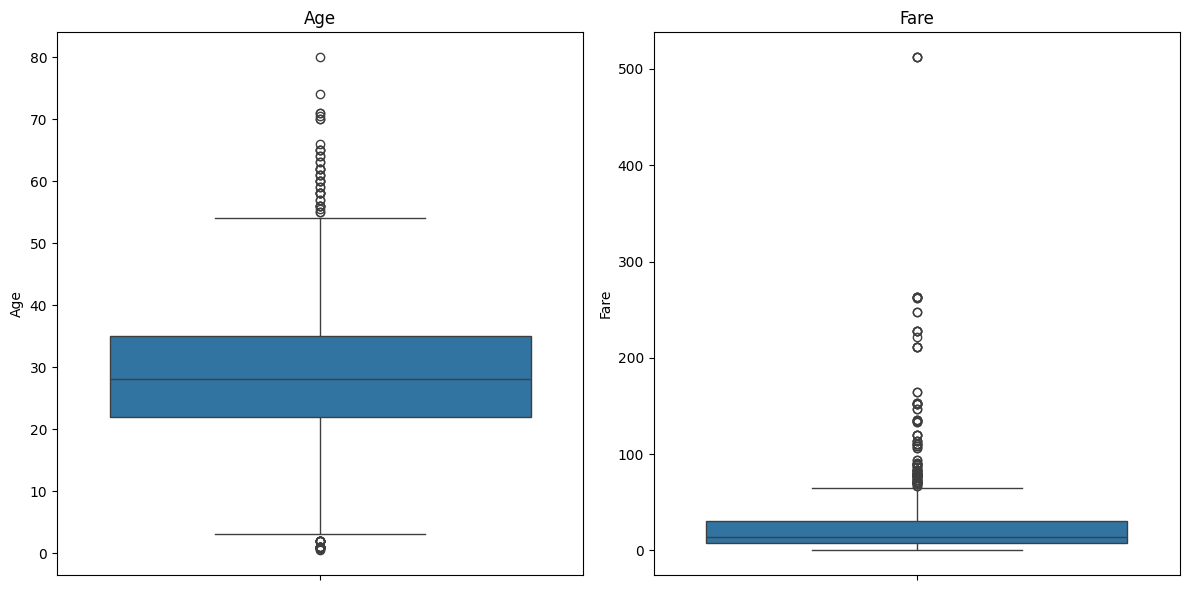

In [11]:
numerical_cols = ['Age', 'Fare']

plt.figure(figsize=(12,6))

for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [12]:
# IQR

outlier_summary = {}

for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_summary[col] = len(outliers)

print("Jumlah Outlier tiap kolom:")
print(outlier_summary)


Jumlah Outlier tiap kolom:
{'Age': 66, 'Fare': 116}


In [16]:
# Hapus Outlier
for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [20]:
df.shape

(718, 8)

### **4. Standarisasi Fitur**

In [23]:
X = df.drop('Survived', axis=1)
y = df['Survived']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [25]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.681465,0.684326,-0.607611,0.686268,-0.40491,-0.751265,0.535130
1,0.681465,-1.461291,-0.207827,-0.484137,-0.40491,-0.700265,0.535130
2,-2.114490,-1.461291,0.691688,0.686268,-0.40491,2.712961,0.535130
3,0.681465,0.684326,0.691688,-0.484137,-0.40491,-0.690821,0.535130
4,0.681465,0.684326,-0.007934,-0.484137,-0.40491,-0.659971,-0.842015


### **5. PCA dengan Sklearn**

In [26]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.27931006 0.2352549  0.15052372 0.12550092 0.10143871 0.07440924
 0.03356246]


In [27]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

variance_df = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance Ratio": explained_variance,
    "Cumulative Variance Ratio": cumulative_variance
})

print(variance_df)

  Principal Component  Explained Variance Ratio  Cumulative Variance Ratio
0                 PC1                  0.279310                   0.279310
1                 PC2                  0.235255                   0.514565
2                 PC3                  0.150524                   0.665089
3                 PC4                  0.125501                   0.790590
4                 PC5                  0.101439                   0.892028
5                 PC6                  0.074409                   0.966438
6                 PC7                  0.033562                   1.000000


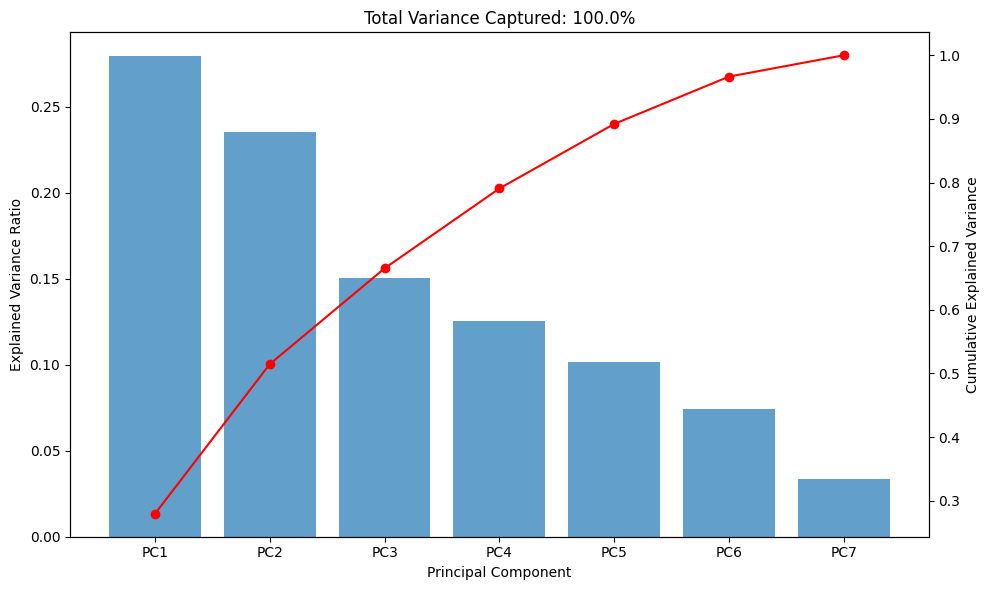

In [ ]:
pcs = [f'PC{i+1}' for i in range(len(explained_variance))]

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(pcs, explained_variance, alpha=0.7)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance Ratio")

ax2 = ax1.twinx()
ax2.plot(pcs, cumulative_variance, color='red', marker='o')
ax2.set_ylabel("Cumulative Explained Variance")

plt.title(f"Total Variance Captured: {cumulative_variance[-1]*100:.1f}%")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [31]:
X_pca = pd.DataFrame(X_pca)

X_pca.columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]

X_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-0.634282,1.059422,0.822863,0.590089,-0.157537,0.388534,-0.248584
1,-0.479794,0.744811,-0.253447,-1.440714,-0.854168,0.323822,0.242351
2,2.624577,-2.428634,0.113524,-0.276821,-1.283275,0.704575,0.588980
3,-1.321756,-0.018757,0.646481,-0.262856,0.524395,0.196115,0.158731
4,-1.207929,0.360560,-0.615441,0.497647,0.496744,-0.040530,0.108347
